<a href="https://colab.research.google.com/github/DefexHunter/DefexHunter-ML/blob/CodeMetricsBased-ML/ExperimentalCode.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Downloading all the needed libs**

In [ ]:
!pip install deap xgboost imbalanced-learn scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.0/136.0 kB 2.3 MB/s eta 0:00:00


--------------------------------------------------------------------------------------------------------------------------

**Uploading the Dataset(JM1) from my PC and replace (y/n) lables with (0/1) numrical values**

In [ ]:
import pandas as pd
from scipy.io import arff

from google.colab import files
uploaded = files.upload()

data, meta = arff.loadarff(list(uploaded.keys())[0])
df = pd.DataFrame(data)

for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].str.decode('utf-8')
df['label'] = df['label'].map({'Y': 1, 'N': 0})

TARGET = "label"
X = df.drop(columns=[TARGET])
y = df[TARGET]

Saving JM1.arff to JM1 (2).arff


--------------------------------------------------------------------------------------------------------------------------

**Preprocessing the extracted Data and balancing it using SMOTE**

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

X_imputed = imputer.fit_transform(X)
X_scaled = scaler.fit_transform(X_imputed)

In [ ]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_bal, y_bal = sm.fit_resample(X_scaled, y)

--------------------------------------------------------------------------------------------------------------------------

**Know the number of cores for the notebook, so I can parallelize the GA and cross-validation work**

In [ ]:
import multiprocessing

n_jobs = multiprocessing.cpu_count()
print("Number of CPU cores detected:", n_jobs)

Number of CPU cores detected: 2


Detected CPU cores: 2
Running GA for SVM...
SVM selected features: 5
Running GA for RandomForest...
RandomForest selected features: 15
Running GA for XGBoost...
XGBoost selected features: 10


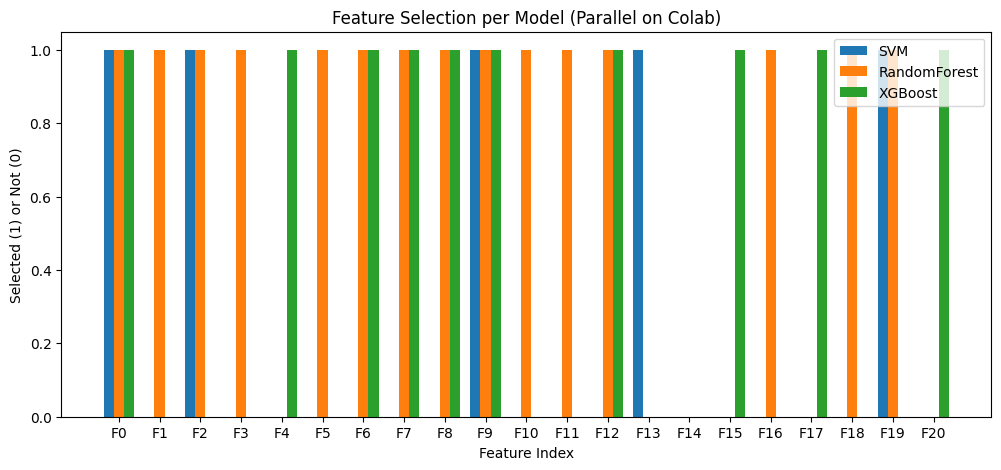

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from deap import base, creator, tools, algorithms
from sklearn.model_selection import cross_val_score
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from joblib import Parallel, delayed
import multiprocessing

n_jobs = multiprocessing.cpu_count()
print("Detected CPU cores:", n_jobs)

n_features = X_bal.shape[1]

# GA evaluation function factory
def make_eval_function(model):
    def eval_features(individual):
        mask = np.array(individual, dtype=bool)
        if mask.sum() == 0:
            return 0,
        X_sel = X_bal[:, mask]
        score = cross_val_score(model, X_sel, y_bal, cv=3, scoring="f1").mean()
        return score,
    return eval_features

# Models to evaluate
models = {
    "SVM": SVC(kernel="rbf", probability=True),
    "RandomForest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric="logloss")
}

best_features = {}

# Helper for parallel evaluation
def parallel_evaluate(toolbox, population):
    fitnesses = Parallel(n_jobs=n_jobs)(delayed(toolbox.evaluate)(ind) for ind in population)
    for ind, fit in zip(population, fitnesses):
        ind.fitness.values = fit
    return population

# GA parameters
pop_size = 30
ngen = 15
cxpb = 0.5
mutpb = 0.2

for model_name, model in models.items():
    print(f"Running GA for {model_name}...")

    # Create unique DEAP classes
    if f"FitnessMax_{model_name}" not in creator.__dict__:
        creator.create(f"FitnessMax_{model_name}", base.Fitness, weights=(1.0,))
    if f"Individual_{model_name}" not in creator.__dict__:
        creator.create(f"Individual_{model_name}", list, fitness=getattr(creator, f"FitnessMax_{model_name}"))

    toolbox = base.Toolbox()
    toolbox.register("attr_bool", np.random.randint, 0, 2)
    toolbox.register("individual", tools.initRepeat, getattr(creator, f"Individual_{model_name}"),
                     toolbox.attr_bool, n=n_features)
    toolbox.register("population", tools.initRepeat, list, toolbox.individual)
    toolbox.register("evaluate", make_eval_function(model))
    toolbox.register("mate", tools.cxTwoPoint)
    toolbox.register("mutate", tools.mutFlipBit, indpb=0.05)
    toolbox.register("select", tools.selTournament, tournsize=3)

    # Initialize population
    pop = toolbox.population(n=pop_size)

    for gen in range(ngen):
        offspring = toolbox.select(pop, len(pop))
        offspring = list(map(toolbox.clone, offspring))

        # Crossover
        for child1, child2 in zip(offspring[::2], offspring[1::2]):
            if np.random.rand() < cxpb:
                toolbox.mate(child1, child2)
                del child1.fitness.values
                del child2.fitness.values

        # Mutation
        for mutant in offspring:
            if np.random.rand() < mutpb:
                toolbox.mutate(mutant)
                del mutant.fitness.values

        # Evaluate invalid individuals in parallel
        invalid_ind = [ind for ind in offspring if not ind.fitness.valid]
        if invalid_ind:
            parallel_evaluate(toolbox, invalid_ind)

        pop[:] = offspring

    # Best individual
    best = tools.selBest(pop, k=1)[0]
    mask = np.array(best, dtype=bool)
    best_features[model_name] = mask
    print(f"{model_name} selected features:", mask.sum())

# --- Visualization ---
plt.figure(figsize=(12, 5))
feature_indices = np.arange(n_features)
width = 0.25

for i, (model_name, mask) in enumerate(best_features.items()):
    plt.bar(feature_indices + i*width, mask.astype(int), width=width, label=model_name)

plt.xlabel("Feature Index")
plt.ylabel("Selected (1) or Not (0)")
plt.title("Feature Selection per Model (Parallel on Colab)")
plt.xticks(feature_indices + width, [f"F{idx}" for idx in range(n_features)])
plt.legend()
plt.show()

--------------------------------------------------------------------------------------------------------------------------

**Exploring the data and the features**

In [ ]:
print(best_features)

{'SVM': array([ True, False,  True, False, False, False, False, False, False,
        True, False, False, False,  True, False, False, False, False,
       False,  True, False]), 'RandomForest': array([ True,  True,  True,  True, False,  True,  True,  True,  True,
        True,  True,  True,  True, False, False, False,  True, False,
        True,  True, False]), 'XGBoost': array([ True, False, False, False,  True, False,  True,  True,  True,
        True, False, False,  True, False, False,  True, False,  True,
       False, False,  True])}


In [ ]:
print(X_bal)
print(y_bal)

[[-0.45866325 -0.21198857 -0.22223716 ... -0.22103432 -0.18062822
  -0.40028329]
 [-0.09439143  1.04157909 -0.22223716 ...  1.29988364  0.81480328
   0.64228804]
 [-0.3675953  -0.4627021  -0.22223716 ... -0.22103432 -0.87743028
  -0.40028329]
 ...
 [-0.5497312  -0.4627021  -0.22223716 ... -0.56973148 -0.77788713
  -0.51307676]
 [-0.00373711 -0.0167361  -0.22223716 ... -0.11733537  0.51617383
  -0.13162915]
 [-0.5497312  -0.453995   -0.22223716 ... -0.57390028 -0.68871517
  -0.50940109]]
0        0
1        0
2        1
3        1
4        0
        ..
12215    1
12216    1
12217    1
12218    1
12219    1
Name: label, Length: 12220, dtype: int64


--------------------------------------------------------------------------------------------------------------------------

**Connecting to Drive and save all the needed work(balanced data, best features for each model, imputer, scaler and SMOTE)**




In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

project_path = "/content/drive/MyDrive/DefexHunter/SavedData"
os.makedirs(project_path, exist_ok=True)

In [ ]:
np.save(f"{project_path}/X_bal.npy",X_bal)

In [ ]:
np.save(f"{project_path}/y_bal.npy",y_bal)

In [ ]:
import pickle

with open(f"{project_path}/best_features.pkl", 'wb') as f:
    pickle.dump(best_features, f)

In [ ]:
checkpoint_preprocess = {
    "X_bal": X_bal,
    "y_bal": y_bal,
    "best_features": best_features,
    "imputer": imputer,
    "scaler": scaler,
    "smote": sm
}

In [ ]:
import pickle
with open(f"{project_path}/checkpoint_preprocess.pkl", 'wb') as f:
    pickle.dump(checkpoint_preprocess, f)

--------------------------------------------------------------------------------------------------------------------------

**Connecting to Drive and Loading the saved data from it**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import pickle

with open(f"{project_path}/checkpoint_preprocess.pkl", "rb") as f:
    checkpoint_preprocess = pickle.load(f)

In [6]:
X_bal = checkpoint_preprocess["X_bal"]
y_bal = checkpoint_preprocess["y_bal"]
imputer = checkpoint_preprocess["imputer"]
scaler = checkpoint_preprocess["scaler"]
sm = checkpoint_preprocess["smote"]
best_features = checkpoint_preprocess["best_features"]


--------------------------------------------------------------------------------------------------------------------------

**Spliting the Data for each model(selected featurs only in the X)**

In [7]:
from sklearn.model_selection import train_test_split

split_data = {}

for model_name, mask in best_features.items():
    print(f"Splitting data for {model_name}...")
    X_sel = X_bal[:, mask]

    # 70% train, 30% temp (validation + test)
    X_train, X_temp, y_train, y_temp = train_test_split(
        X_sel, y_bal, test_size=0.3, random_state=42, stratify=y_bal
    )

    # 50% of temp for validation, 50% of temp for test (i.e., 15% val, 15% test of original)
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
    )

    split_data[model_name] = {
        "X_train": X_train,
        "y_train": y_train,
        "X_val": X_val,
        "y_val": y_val,
        "X_test": X_test,
        "y_test": y_test,
    }

print("Data splitting complete for all models.")

Splitting data for SVM...
Splitting data for RandomForest...
Splitting data for XGBoost...
Data splitting complete for all models.


--------------------------------------------------------------------------------------------------------------------------

**Training The Random Forest Model and appling GrideSearchCV to select the best model using the best parameters
and validating**

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report

X_train = split_data['RandomForest']['X_train']
y_train = split_data['RandomForest']['y_train']

param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid_rf,
    scoring='f1',  # use 'f1_macro' if multiclass
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_

print("Best RF Parameters:")
print(grid_rf.best_params_)

print("Best RF CV F1 Score:")
print(grid_rf.best_score_)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best RF Parameters:
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best RF CV F1 Score:
0.8604336019184704


In [9]:
X_val = split_data['RandomForest']['X_val']
y_val = split_data['RandomForest']['y_val']

y_val_pred = best_rf.predict(X_val)
print(classification_report(y_val, y_val_pred))

              precision    recall  f1-score   support

           0       0.86      0.87      0.86       916
           1       0.87      0.86      0.86       917

    accuracy                           0.86      1833
   macro avg       0.86      0.86      0.86      1833
weighted avg       0.86      0.86      0.86      1833



--------------------------------------------------------------------------------------------------------------------------

**Training The XGBoost Model and appling GrideSearchCV to select the best model using the best parameters
and validating**

In [10]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report

X_train = split_data['XGBoost']['X_train']
y_train = split_data['XGBoost']['y_train']

param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_xgb = GridSearchCV(
    estimator=XGBClassifier(
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42
    ),
    param_grid=param_grid_xgb,
    scoring='f1',  # or 'f1_macro'
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_xgb.fit(X_train, y_train)

best_xgb = grid_xgb.best_estimator_

print("Best XGB Parameters:")
print(grid_xgb.best_params_)

print("Best XGB CV F1 Score:")
print(grid_xgb.best_score_)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:34:29] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best XGB Parameters:
{'colsample_bytree': 1.0, 'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 300, 'subsample': 1.0}
Best XGB CV F1 Score:
0.8402647291433322


In [11]:
X_val = split_data['XGBoost']['X_val']
y_val = split_data['XGBoost']['y_val']

y_val_pred = best_xgb.predict(X_val)
print(classification_report(y_val, y_val_pred))

              precision    recall  f1-score   support

           0       0.83      0.87      0.85       916
           1       0.86      0.82      0.84       917

    accuracy                           0.84      1833
   macro avg       0.84      0.84      0.84      1833
weighted avg       0.84      0.84      0.84      1833



--------------------------------------------------------------------------------------------------------------------------

**Training The SVM Model and appling GrideSearchCV to select the best model using the best parameters
and validating**

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report

X_train = split_data['SVM']['X_train']
y_train = split_data['SVM']['y_train']

param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['rbf', 'linear'],
    'gamma': ['scale', 'auto', 0.01, 0.001]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_svm = GridSearchCV(
    estimator=SVC(probability=True),
    param_grid=param_grid,
    scoring='f1',      # change to 'f1_macro' if multiclass
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_svm.fit(X_train, y_train)

best_svm = grid_svm.best_estimator_

print("Best SVM Parameters:")
print(grid_svm.best_params_)

print("Best SVM CV F1 Score:")
print(grid_svm.best_score_)

In [ ]:
X_val = split_data['SVM']['X_val']
y_val = split_data['SVM']['y_val']

y_val_pred = best_svm.predict(X_val)
print(classification_report(y_val, y_val_pred))

--------------------------------------------------------------------------------------------------------------------------